# Imagens coloridas

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dir_flower = Path("../../dados/flower")

img = Image.open(dir_flower / "flower.tiff")
# Converte a imagem para um array numpy
img_np = np.array(img)
print(img_np.shape)

(755, 800, 4)


In [11]:
# Acessando o pixel na posição (100, 100) da imagem
pixel = img_np[100, 100]
print(f"Red: {pixel[0]}, Green: {pixel[1]}, Blue: {pixel[2]}, Alpha: {pixel[3]}")

Red: 45, Green: 70, Blue: 2, Alpha: 255


O pixel (100, 100) possui intensidade 45 de vermelho, 70 de verde e 2 de azul. O valor alpha de 255 indica que o pixel não possui transparência.

A grande maioria das imagens no padrão RGBA utilizadas em processamento de imagens possui o valor 255 no canal alpha para todos os pixels.

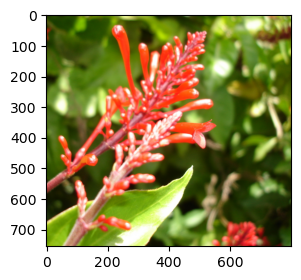

In [5]:
plt.imshow(img)

A biblioteca PIL (Pillow) permite converter uma imagem RGBA para RGB, mas isso consiste em basicamente eliminar o quarto canal:

In [12]:
img = img.convert("RGB")
img_np = np.array(img)
print(img_np.shape)

(755, 800, 3)


## Visualizando cada canal de cor separadamente

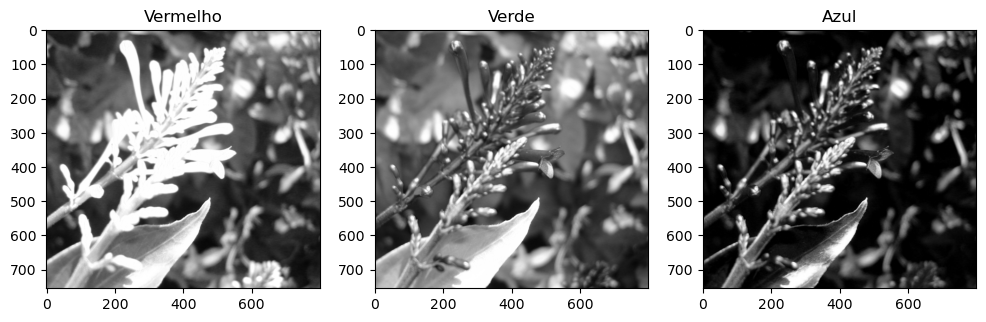

In [15]:
def imshow(img):
    # vmin define o valor associado ao preto e vmax o valor da cor branca
    plt.imshow(img, "gray", vmin=0, vmax=255)  

img_red = img_np[:,:,0]     # Matriz contendo o canal vermelho
img_green = img_np[:,:,1]   # Matriz contendo o canal verde
img_blue = img_np[:,:,2]    # Matriz contendo o canal azul

plt.figure(figsize=[12, 4])
plt.subplot(1, 3, 1)

imshow(img_red)  
plt.title("Vermelho")
plt.subplot(1, 3, 2)
imshow(img_green)
plt.title("Verde")
plt.subplot(1, 3, 3)
imshow(img_blue)
plt.title("Azul");

## Transformação de intensidade

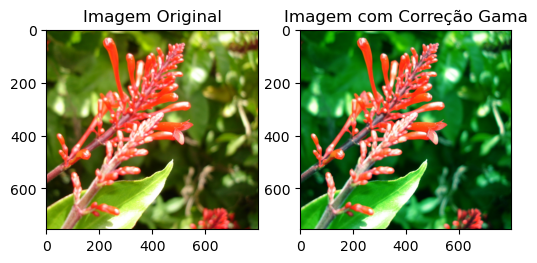

In [ ]:
def gamma_correction(img, gamma_r, gamma_g, gamma_b):
    """Transformação gamma de uma imagem colorida. Cada gamma define o expoente da 
    transformação para o respectivo canal de cor."""
    # Normaliza os valores dos pixels para o intervalo [0, 1]
    img_normalized = img / 255.0
    
    # Aplica a correção gama para cada canal
    img_corrected = np.zeros_like(img_normalized)
    img_corrected[:,:,0] = img_normalized[:,:,0]**gamma_r  # Canal vermelho
    img_corrected[:,:,1] = img_normalized[:,:,1]**gamma_g  # Canal verde
    img_corrected[:,:,2] = img_normalized[:,:,2]**gamma_b  # Canal azul
    
    # Escala de volta para o intervalo [0, 255]
    img_corrected = (img_corrected * 255).astype(np.uint8)
    
    return img_corrected

gamma_r = 3
gamma_g = 1
gamma_b = 1

img_corrected = gamma_correction(img_np, gamma_r, gamma_g, gamma_b)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].set_title("Imagem Original")
ax[0].imshow(img_np)
ax[1].set_title("Imagem com Correção Gama")
ax[1].imshow(img_corrected)


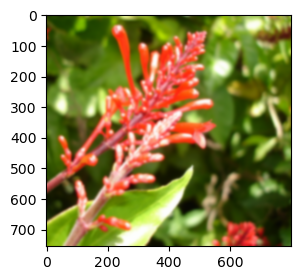

In [40]:
from scipy.ndimage import gaussian_filter

def blur_color_image(img, sigma):
    """Aplica um filtro gaussiano a cada canal de uma imagem colorida."""
    img_blurred = np.zeros_like(img)
    # Para cada canal (R, G, B)
    for c in range(3):  
        img_blurred[:,:,c] = gaussian_filter(img[:,:,c], sigma=sigma)
    return img_blurred

img_red_blur = blur_color_image(img_np, sigma=3)
plt.imshow(img_red_blur)

### Conversão de imagem colorida para nível de cinza

Se quisermos converter a imagem para níveis de cinza, utilizamos a fórmula

img_gray = 0.299\*img_red + 0.587\*img_green + 0.114\*img_blue

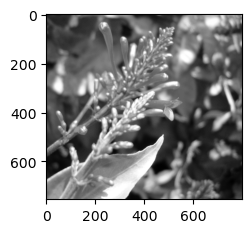

In [5]:
def rgb2gray(img):
    img_gray = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
    return img_gray

img_gray = rgb2gray(img)
plt.imshow(img_gray, "gray")

# Formatos de imagem

Diferentes formatos podem armazenar imagens de forma ligeiramente diferentes, e serem lidos de maneira diferente por softwares e bibliotecas.

In [ ]:
img = plt.imread(dir_flower / "flower.tiff")
print(np.max(img), img.shape)

img = plt.imread(dir_flower / "flower.jpg")
print(np.max(img), img.shape)

img = plt.imread(dir_flower / "flower.png")
print(np.max(img), img.shape)

255 (755, 800, 4)
255 (755, 800, 3)
1.0 (755, 800, 3)


O matplotlib lê imagens png com valores entre 0 e 1. Podemos trabalhar com os pixels nesse intervalo de valores ou então converter a imagem para valores inteiros no intervalo [0,255] fazendo

In [6]:
img_255 = np.round(255*img).astype(np.uint8)